<a href="https://colab.research.google.com/github/rinkab23-gif/Best-Project-to-skill-up/blob/main/adversarial_attack.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

100%|██████████| 170M/170M [00:04<00:00, 42.4MB/s]


✅ Training samples: 50000
✅ Test samples: 10000


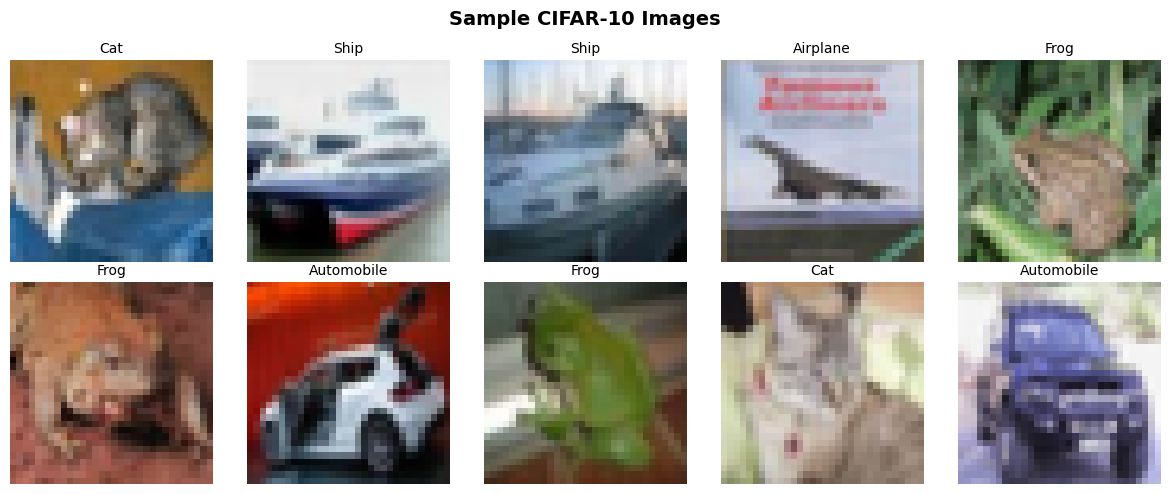

In [1]:
import torchvision
import torchvision.transforms as transforms
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt

# CIFAR-10 class names
classes = ('Airplane', 'Automobile', 'Bird', 'Cat', 'Deer',
           'Dog', 'Frog', 'Horse', 'Ship', 'Truck')

# Data transforms
transform_train = transforms.Compose([
    transforms.RandomHorizontalFlip(),
    transforms.RandomCrop(32, padding=4),
    transforms.ToTensor(),
])

transform_test = transforms.Compose([
    transforms.ToTensor(),
])

# Download datasets
trainset = torchvision.datasets.CIFAR10(root='./data', train=True, download=True, transform=transform_train)
testset = torchvision.datasets.CIFAR10(root='./data', train=False, download=True, transform=transform_test)

trainloader = DataLoader(trainset, batch_size=128, shuffle=True, num_workers=2)
testloader = DataLoader(testset, batch_size=100, shuffle=False, num_workers=2)

print(f'✅ Training samples: {len(trainset)}')
print(f'✅ Test samples: {len(testset)}')

# Visualize sample images
fig, axes = plt.subplots(2, 5, figsize=(12, 5))
for i in range(10):
    img, label = testset[i]
    ax = axes[i // 5][i % 5]
    ax.imshow(img.permute(1, 2, 0).numpy())
    ax.set_title(classes[label], fontsize=10)
    ax.axis('off')
plt.suptitle('Sample CIFAR-10 Images', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

In [2]:
import torch
import torch.nn as nn
import torch.nn.functional as F

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

class CNN(nn.Module):
    """A robust CNN architecture for CIFAR-10 classification."""
    def __init__(self):
        super(CNN, self).__init__() # Corrected: added parentheses here
        # Convolutional Block 1
        self.conv1 = nn.Conv2d(3, 64, 3, padding=1)
        self.bn1 = nn.BatchNorm2d(64)
        self.conv2 = nn.Conv2d(64, 64, 3, padding=1)
        self.bn2 = nn.BatchNorm2d(64)
        self.pool1 = nn.MaxPool2d(2, 2)
        self.drop1 = nn.Dropout(0.25)

        # Convolutional Block 2
        self.conv3 = nn.Conv2d(64, 128, 3, padding=1)
        self.bn3 = nn.BatchNorm2d(128)
        self.conv4 = nn.Conv2d(128, 128, 3, padding=1)
        self.bn4 = nn.BatchNorm2d(128)
        self.pool2 = nn.MaxPool2d(2, 2)
        self.drop2 = nn.Dropout(0.25)

        # Fully Connected Layers
        self.fc1 = nn.Linear(128 * 8 * 8, 256)
        self.bn5 = nn.BatchNorm1d(256)
        self.drop3 = nn.Dropout(0.5)
        self.fc2 = nn.Linear(256, 10)

    def forward(self, x):
        # Block 1
        x = F.relu(self.bn1(self.conv1(x)))
        x = F.relu(self.bn2(self.conv2(x)))
        x = self.drop1(self.pool1(x))
        # Block 2
        x = F.relu(self.bn3(self.conv3(x)))
        x = F.relu(self.bn4(self.conv4(x)))
        x = self.drop2(self.pool2(x))
        # Classifier
        x = x.view(x.size(0), -1)
        x = F.relu(self.bn5(self.fc1(x)))
        x = self.drop3(x)
        x = self.fc2(x)
        return x

model = CNN().to(device)
print('✅ Model Architecture:')
print(model)
total_params = sum(p.numel() for p in model.parameters())
print(f'\n📊 Total Parameters: {total_params:,}')

✅ Model Architecture:
CNN(
  (conv1): Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (pool1): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (drop1): Dropout(p=0.25, inplace=False)
  (conv3): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (bn3): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (conv4): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (bn4): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (pool2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (drop2): Dropout(p=0.25, inplace=False)
  (fc1): Linear(in_features=8192, out_features=25

In [3]:
import torch
import torch.nn as nn
import torch.optim as optim

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

def train_model(model, trainloader, epochs=15, lr=0.001):
    """Train the model and return training history."""
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=lr)
    scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=5, gamma=0.5)
    history = {'loss': [], 'acc': []}

    model.train()
    for epoch in range(epochs):
        running_loss = 0.0
        correct = 0
        total = 0
        for images, labels in trainloader:
            images, labels = images.to(device), labels.to(device)
            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            running_loss += loss.item()
            _, predicted = outputs.max(1)
            total += labels.size(0)
            correct += predicted.eq(labels).sum().item()

        scheduler.step()
        epoch_loss = running_loss / len(trainloader)
        epoch_acc = 100. * correct / total
        history['loss'].append(epoch_loss)
        history['acc'].append(epoch_acc)
        print(f'Epoch [{epoch+1}/{epochs}] Loss: {epoch_loss:.4f} | Acc: {epoch_acc:.2f}%')

    return history

print('🚀 Training Standard Model...')
print('=' * 50)
standard_model = CNN().to(device)
standard_history = train_model(standard_model, trainloader, epochs=15)
print('\n✅ Standard Model Training Complete!')

🚀 Training Standard Model...
Epoch [1/15] Loss: 1.3916 | Acc: 49.26%
Epoch [2/15] Loss: 1.0160 | Acc: 63.83%
Epoch [3/15] Loss: 0.8885 | Acc: 68.51%
Epoch [4/15] Loss: 0.8219 | Acc: 71.00%
Epoch [5/15] Loss: 0.7695 | Acc: 72.94%
Epoch [6/15] Loss: 0.6817 | Acc: 76.17%
Epoch [7/15] Loss: 0.6563 | Acc: 77.09%
Epoch [8/15] Loss: 0.6258 | Acc: 78.27%
Epoch [9/15] Loss: 0.6080 | Acc: 78.72%
Epoch [10/15] Loss: 0.5906 | Acc: 79.40%
Epoch [11/15] Loss: 0.5456 | Acc: 81.13%
Epoch [12/15] Loss: 0.5326 | Acc: 81.52%
Epoch [13/15] Loss: 0.5201 | Acc: 82.02%
Epoch [14/15] Loss: 0.5070 | Acc: 82.53%
Epoch [15/15] Loss: 0.5007 | Acc: 82.49%

✅ Standard Model Training Complete!


In [4]:
def evaluate(model, testloader):
    """Evaluate model accuracy on the test set."""
    model.eval()
    correct = 0
    total = 0
    class_correct = [0] * 10
    class_total = [0] * 10
    with torch.no_grad():
        for images, labels in testloader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            _, predicted = outputs.max(1)
            total += labels.size(0)
            correct += predicted.eq(labels).sum().item()
            for i in range(labels.size(0)):
                label = labels[i].item()
                class_correct[label] += (predicted[i] == labels[i]).item()
                class_total[label] += 1

    overall_acc = 100. * correct / total
    class_acc = {classes[i]: 100. * class_correct[i] / class_total[i] if class_total[i] > 0 else 0 for i in range(10)}
    return overall_acc, class_acc

clean_acc, clean_class_acc = evaluate(standard_model, testloader)
print(f'🎯 Standard Model Accuracy on CLEAN images: {clean_acc:.2f}%')
print('\n📊 Per-Class Accuracy:')
for cls, acc in clean_class_acc.items():
    print(f'   {cls:12s}: {acc:.2f}%')

🎯 Standard Model Accuracy on CLEAN images: 85.14%

📊 Per-Class Accuracy:
   Airplane    : 91.10%
   Automobile  : 94.00%
   Bird        : 78.00%
   Cat         : 61.90%
   Deer        : 85.70%
   Dog         : 77.30%
   Frog        : 92.40%
   Horse       : 88.00%
   Ship        : 93.40%
   Truck       : 89.60%


***Adversarial Attack Implementation***

###  FGSM (Fast Gradient Sign Method)
FGSM perturbs the input image in the direction of the gradient to maximize the loss.

**Formula:** `x_adv = x + ε × sign(∇x L(θ, x, y))`

### **PGD** (Projected Gradient Descent)
PGD is an iterative version of FGSM — stronger and more reliable attack.

In [5]:
def fgsm_attack(model, images, labels, epsilon):
    """
    FGSM Attack: Single-step gradient-based perturbation.
    Args:
        model: Target model
        images: Original clean images
        labels: True labels
        epsilon: Perturbation magnitude (0 to 1)
    Returns:
        Adversarial images
    """
    images.requires_grad = True
    outputs = model(images)
    loss = F.cross_entropy(outputs, labels)
    model.zero_grad()
    loss.backward()
    # Generate perturbation
    perturbation = epsilon * images.grad.data.sign()
    # Create adversarial image
    adv_images = images + perturbation
    adv_images = torch.clamp(adv_images, 0, 1)  # Keep pixel values valid
    return adv_images.detach()


def pgd_attack(model, images, labels, epsilon, alpha=2/255, num_steps=10):
    """
    PGD Attack: Multi-step iterative attack (stronger than FGSM).
    Args:
        model: Target model
        images: Original clean images
        labels: True labels
        epsilon: Maximum perturbation
        alpha: Step size per iteration
        num_steps: Number of attack iterations
    Returns:
        Adversarial images
    """
    adv_images = images.clone().detach()
    original_images = images.clone().detach()

    for _ in range(num_steps):
        adv_images.requires_grad = True
        outputs = model(adv_images)
        loss = F.cross_entropy(outputs, labels)
        model.zero_grad()
        loss.backward()
        # Take a step
        adv_images = adv_images + alpha * adv_images.grad.sign()
        # Project back to epsilon ball
        delta = torch.clamp(adv_images - original_images, -epsilon, epsilon)
        adv_images = torch.clamp(original_images + delta, 0, 1).detach()

    return adv_images

print('✅ FGSM and PGD attack functions defined!')

✅ FGSM and PGD attack functions defined!


 ***Visualize Original vs Adversarial Images***

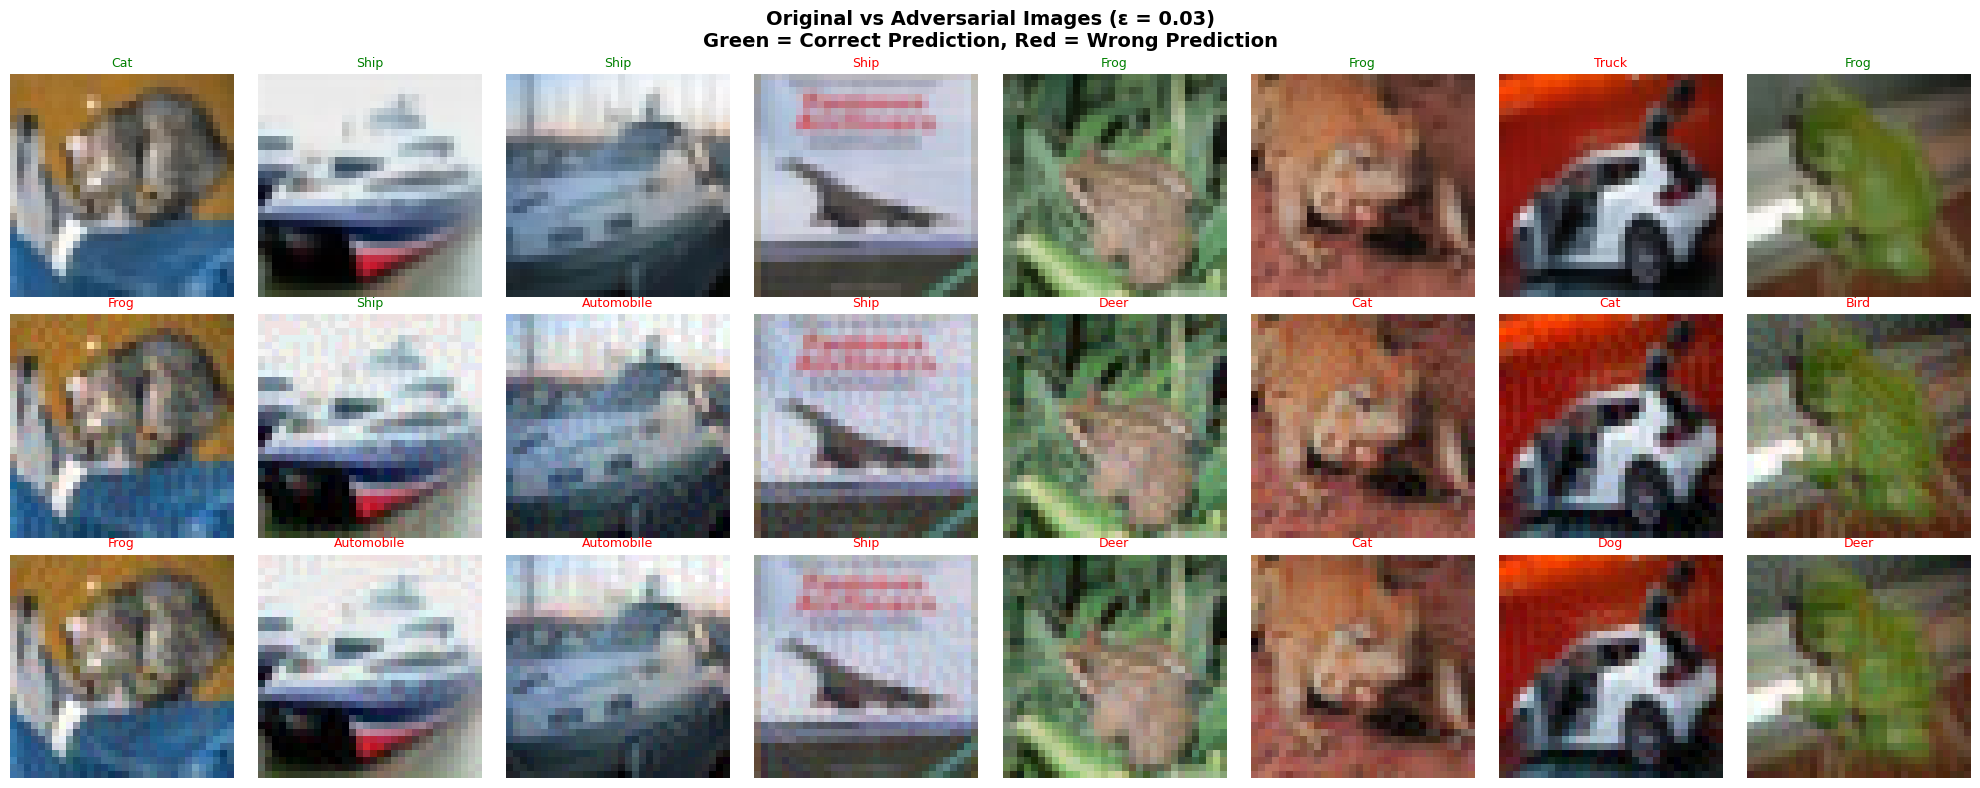

In [6]:
def visualize_attacks(model, testloader, epsilon=0.03):
    """Show original, FGSM-attacked, and PGD-attacked images side by side."""
    model.eval()
    images, labels = next(iter(testloader))
    images, labels = images[:8].to(device), labels[:8].to(device)

    # Generate attacks
    fgsm_images = fgsm_attack(model, images.clone(), labels, epsilon)
    pgd_images = pgd_attack(model, images.clone(), labels, epsilon)

    # Get predictions
    with torch.no_grad():
        orig_preds = model(images).argmax(1)
        fgsm_preds = model(fgsm_images).argmax(1)
        pgd_preds = model(pgd_images).argmax(1)

    fig, axes = plt.subplots(3, 8, figsize=(20, 8))
    row_titles = ['Original', 'FGSM Attack', 'PGD Attack']

    for i in range(8):
        # Original
        axes[0][i].imshow(images[i].cpu().permute(1,2,0).numpy())
        color = 'green' if orig_preds[i] == labels[i] else 'red'
        axes[0][i].set_title(f'{classes[orig_preds[i]]}', color=color, fontsize=9)
        axes[0][i].axis('off')

        # FGSM
        axes[1][i].imshow(fgsm_images[i].cpu().permute(1,2,0).numpy())
        color = 'green' if fgsm_preds[i] == labels[i] else 'red'
        axes[1][i].set_title(f'{classes[fgsm_preds[i]]}', color=color, fontsize=9)
        axes[1][i].axis('off')

        # PGD
        axes[2][i].imshow(pgd_images[i].cpu().permute(1,2,0).numpy())
        color = 'green' if pgd_preds[i] == labels[i] else 'red'
        axes[2][i].set_title(f'{classes[pgd_preds[i]]}', color=color, fontsize=9)
        axes[2][i].axis('off')

    for idx, title in enumerate(row_titles):
        axes[idx][0].set_ylabel(title, fontsize=12, fontweight='bold', rotation=0, labelpad=80)

    plt.suptitle(f'Original vs Adversarial Images (ε = {epsilon})\n'
                 f'Green = Correct Prediction, Red = Wrong Prediction',
                 fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()

visualize_attacks(standard_model, testloader, epsilon=0.03)

***##Measure Accuracy Drop Under Different Attack Strengths***

📊 Evaluating accuracy under attacks...
   Epsilon |   FGSM Acc |    PGD Acc |  FGSM Drop |   PGD Drop
------------------------------------------------------------
     0.000 |     85.14% |     85.14% |      0.00% |      0.00%
     0.005 |     45.03% |     40.10% |     40.11% |     45.04%
     0.010 |     20.06% |      5.98% |     65.08% |     79.16%
     0.020 |      5.45% |      0.05% |     79.69% |     85.09%
     0.030 |      3.76% |      0.00% |     81.38% |     85.14%
     0.050 |      3.51% |      0.00% |     81.63% |     85.14%
     0.100 |      5.15% |      0.00% |     79.99% |     85.14%


/tmp/ipykernel_1457/1614127149.py:45: UserWarning: Glyph 128201 (\N{CHART WITH DOWNWARDS TREND}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128201 (\N{CHART WITH DOWNWARDS TREND}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


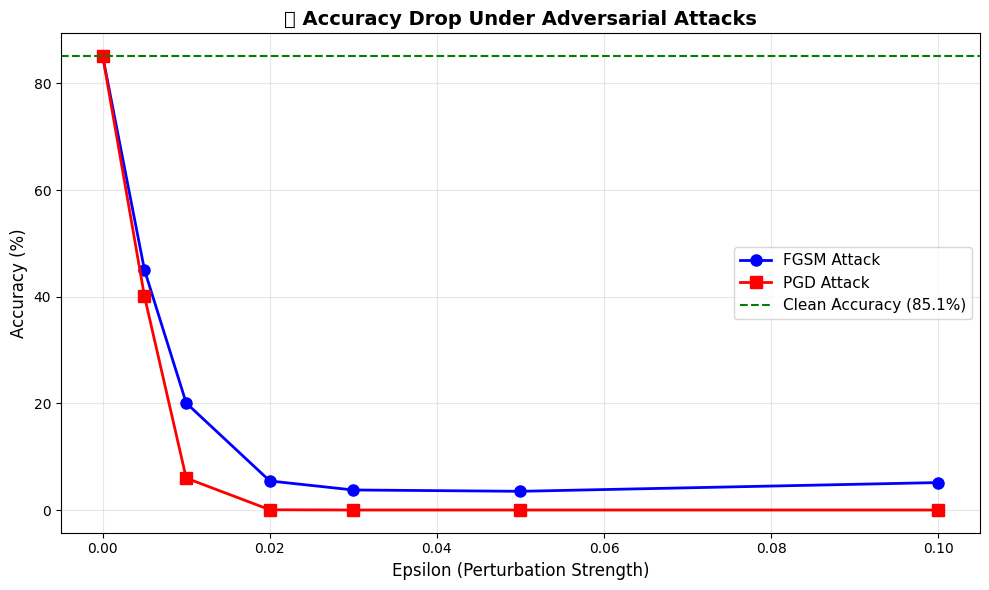

In [9]:
def evaluate_under_attack(model, testloader, attack_fn, epsilon):
    """Evaluate model accuracy under a specific attack."""
    model.eval()
    correct = 0
    total = 0
    for images, labels in testloader:
        images, labels = images.to(device), labels.to(device)
        adv_images = attack_fn(model, images, labels, epsilon)
        with torch.no_grad():
            outputs = model(adv_images)
            _, predicted = outputs.max(1)
            total += labels.size(0)
            correct += predicted.eq(labels).sum().item()
    return 100. * correct / total

# Test multiple epsilon values
epsilons = [0, 0.005, 0.01, 0.02, 0.03, 0.05, 0.1]
fgsm_accs = []
pgd_accs = []

print('📊 Evaluating accuracy under attacks...')
print(f'{"Epsilon":>10} | {"FGSM Acc":>10} | {"PGD Acc":>10} | {"FGSM Drop":>10} | {"PGD Drop":>10}')
print('-' * 60)

for eps in epsilons:
    if eps == 0:
        fgsm_acc = pgd_acc = clean_acc
    else:
        fgsm_acc = evaluate_under_attack(standard_model, testloader, fgsm_attack, eps)
        pgd_acc = evaluate_under_attack(standard_model, testloader, pgd_attack, eps)
    fgsm_accs.append(fgsm_acc)
    pgd_accs.append(pgd_acc)
    print(f'{eps:>10.3f} | {fgsm_acc:>9.2f}% | {pgd_acc:>9.2f}% | {clean_acc - fgsm_acc:>9.2f}% | {clean_acc - pgd_acc:>9.2f}%')

# Plot accuracy vs epsilon
plt.figure(figsize=(10, 6))
plt.plot(epsilons, fgsm_accs, 'bo-', linewidth=2, markersize=8, label='FGSM Attack')
plt.plot(epsilons, pgd_accs, 'rs-', linewidth=2, markersize=8, label='PGD Attack')
plt.axhline(y=clean_acc, color='green', linestyle='--', linewidth=1.5, label=f'Clean Accuracy ({clean_acc:.1f}%)')
plt.xlabel('Epsilon (Perturbation Strength)', fontsize=12)
plt.ylabel('Accuracy (%)', fontsize=12)
plt.title('📉 Accuracy Drop Under Adversarial Attacks', fontsize=14, fontweight='bold')
plt.legend(fontsize=11)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

*##**Adversarial Training (Building a Robust Model)***

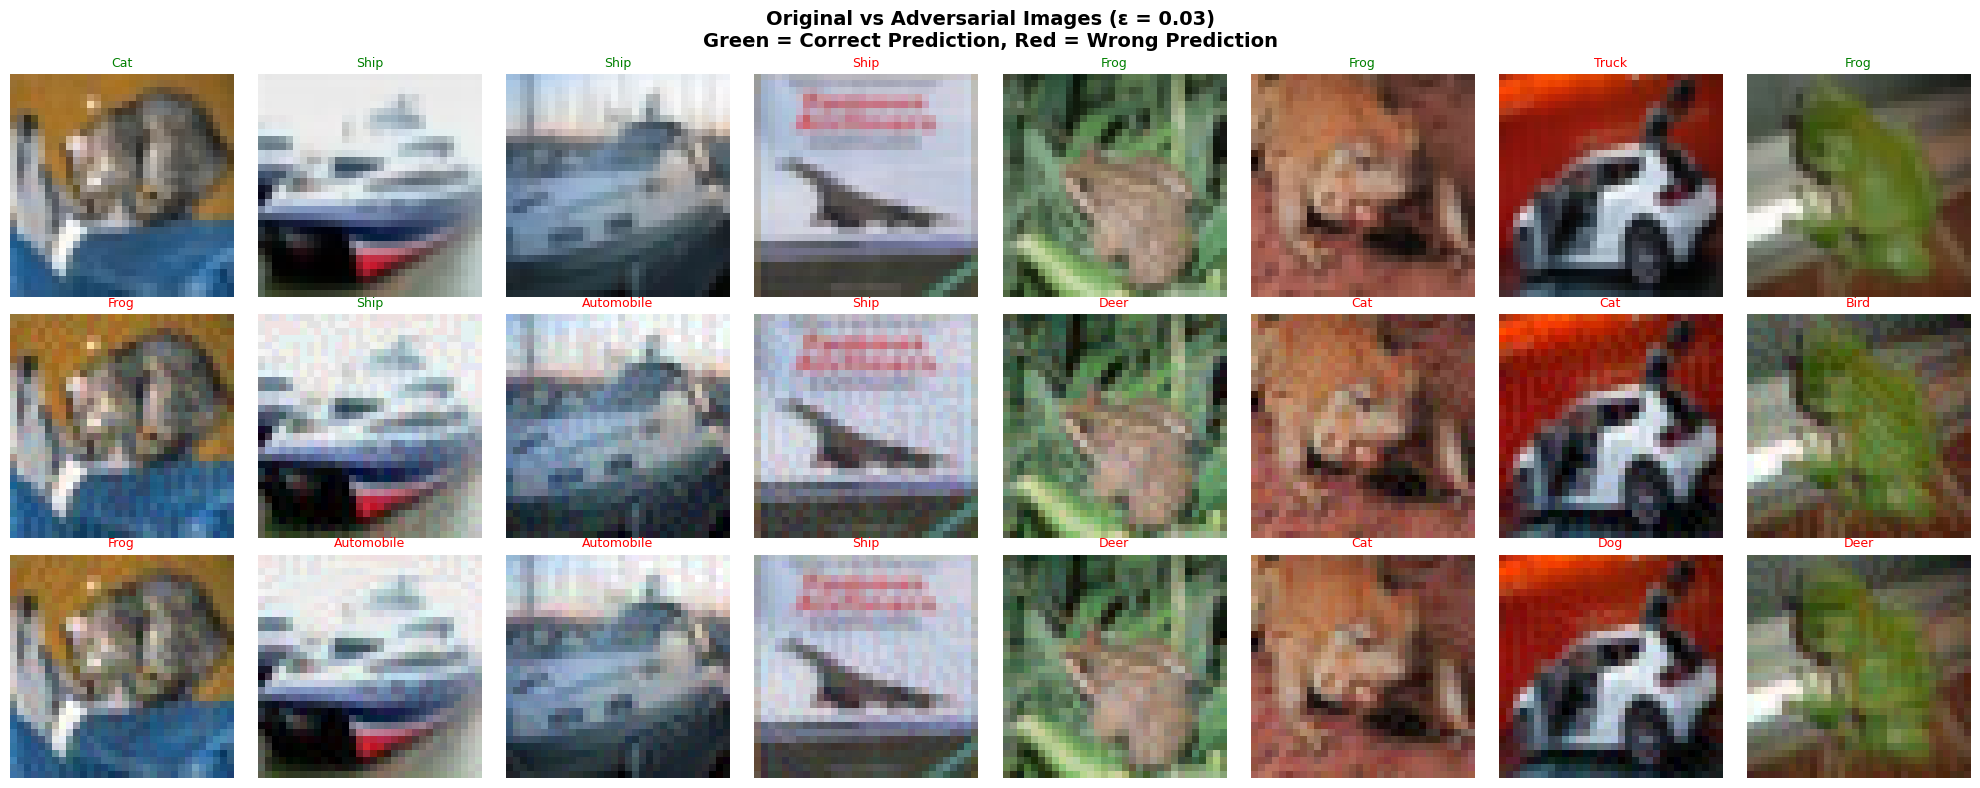

In [8]:
def visualize_attacks(model, testloader, epsilon=0.03):
    """Show original, FGSM-attacked, and PGD-attacked images side by side."""
    model.eval()
    images, labels = next(iter(testloader))
    images, labels = images[:8].to(device), labels[:8].to(device)

    # Generate attacks
    fgsm_images = fgsm_attack(model, images.clone(), labels, epsilon)
    pgd_images = pgd_attack(model, images.clone(), labels, epsilon)

    # Get predictions
    with torch.no_grad():
        orig_preds = model(images).argmax(1)
        fgsm_preds = model(fgsm_images).argmax(1)
        pgd_preds = model(pgd_images).argmax(1)

    fig, axes = plt.subplots(3, 8, figsize=(20, 8))
    row_titles = ['Original', 'FGSM Attack', 'PGD Attack']

    for i in range(8):
        # Original
        axes[0][i].imshow(images[i].cpu().permute(1,2,0).numpy())
        color = 'green' if orig_preds[i] == labels[i] else 'red'
        axes[0][i].set_title(f'{classes[orig_preds[i]]}', color=color, fontsize=9)
        axes[0][i].axis('off')

        # FGSM
        axes[1][i].imshow(fgsm_images[i].cpu().permute(1,2,0).numpy())
        color = 'green' if fgsm_preds[i] == labels[i] else 'red'
        axes[1][i].set_title(f'{classes[fgsm_preds[i]]}', color=color, fontsize=9)
        axes[1][i].axis('off')

        # PGD
        axes[2][i].imshow(pgd_images[i].cpu().permute(1,2,0).numpy())
        color = 'green' if pgd_preds[i] == labels[i] else 'red'
        axes[2][i].set_title(f'{classes[pgd_preds[i]]}', color=color, fontsize=9)
        axes[2][i].axis('off')

    for idx, title in enumerate(row_titles):
        axes[idx][0].set_ylabel(title, fontsize=12, fontweight='bold', rotation=0, labelpad=80)

    plt.suptitle(f'Original vs Adversarial Images (ε = {epsilon})\n'
                 f'Green = Correct Prediction, Red = Wrong Prediction',
                 fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()

visualize_attacks(standard_model, testloader, epsilon=0.03)

***## Compare Standard vs Robust Model***

🚀 Training Robust Model (Adversarial Training)...
Robust Epoch [1/15] Loss: 2.0393 | Acc: 23.82%
Robust Epoch [2/15] Loss: 1.9058 | Acc: 28.78%
Robust Epoch [3/15] Loss: 1.8509 | Acc: 30.83%
Robust Epoch [4/15] Loss: 1.8119 | Acc: 31.94%
Robust Epoch [5/15] Loss: 1.7839 | Acc: 33.03%
Robust Epoch [6/15] Loss: 1.7395 | Acc: 34.64%
Robust Epoch [7/15] Loss: 1.7249 | Acc: 35.28%
Robust Epoch [8/15] Loss: 1.7074 | Acc: 35.91%
Robust Epoch [9/15] Loss: 1.6967 | Acc: 36.47%
Robust Epoch [10/15] Loss: 1.6902 | Acc: 36.74%
Robust Epoch [11/15] Loss: 1.6673 | Acc: 37.59%
Robust Epoch [12/15] Loss: 1.6519 | Acc: 38.20%
Robust Epoch [13/15] Loss: 1.6462 | Acc: 38.21%
Robust Epoch [14/15] Loss: 1.6415 | Acc: 38.28%
Robust Epoch [15/15] Loss: 1.6359 | Acc: 38.95%

✅ Robust Model Training Complete!
📊 Comparing Standard vs Robust Model...
 Epsilon |   Std FGSM |   Rob FGSM |    Std PGD |    Rob PGD
-----------------------------------------------------------------
   0.000 |     85.14% |     64.42% | 

/tmp/ipykernel_1457/2211021576.py:97: UserWarning: Glyph 128737 (\N{SHIELD}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128737 (\N{SHIELD}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


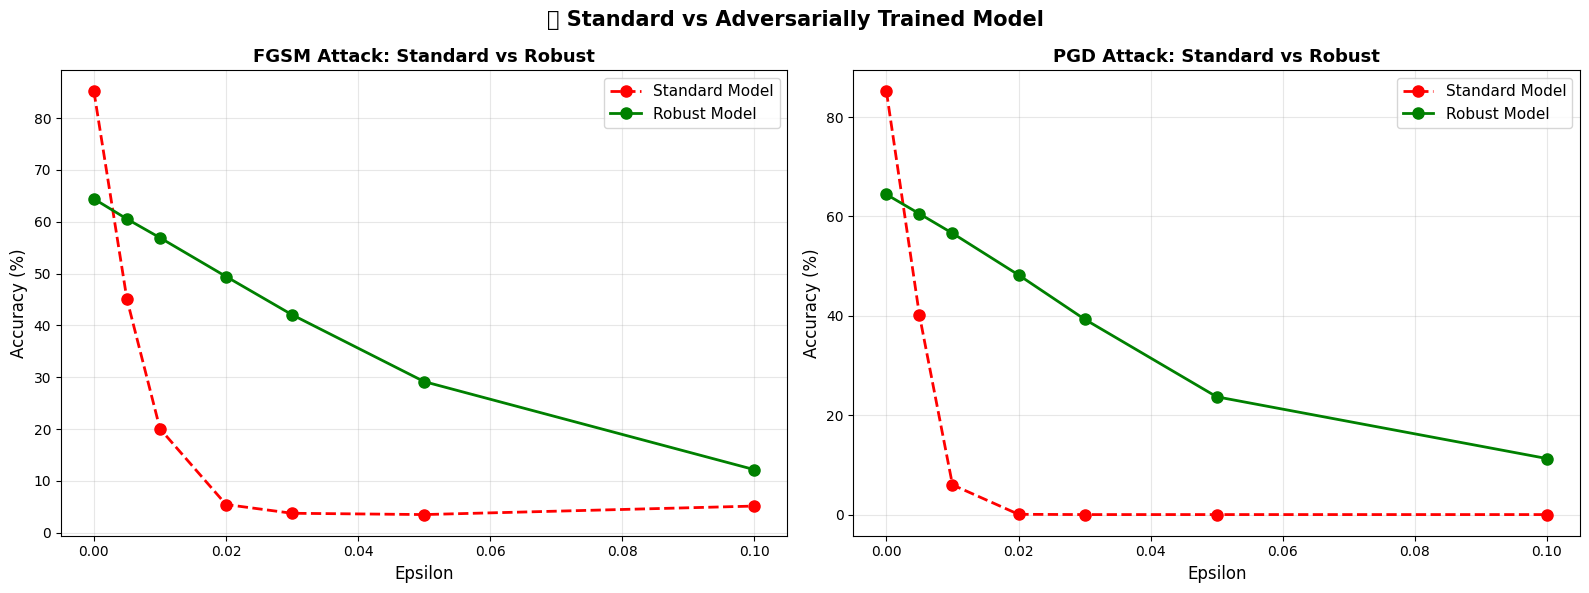

In [16]:
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F

# Function for Adversarial Training
def adversarial_train_model(model, trainloader, fgsm_attack, pgd_attack, epochs=15, lr=0.001, epsilon=0.03):
    """Adversarially train the model using PGD attack during training."""
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=lr)
    scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=5, gamma=0.5)
    history = {'loss': [], 'acc': []}

    model.train()
    for epoch in range(epochs):
        running_loss = 0.0
        correct = 0
        total = 0
        for images, labels in trainloader:
            images, labels = images.to(device), labels.to(device)

            # Generate adversarial examples using PGD for training
            adv_images = pgd_attack(model, images, labels, epsilon)

            optimizer.zero_grad()
            outputs = model(adv_images) # Train on adversarial examples
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            running_loss += loss.item()
            _, predicted = outputs.max(1)
            total += labels.size(0)
            correct += predicted.eq(labels).sum().item()

        scheduler.step()
        epoch_loss = running_loss / len(trainloader)
        epoch_acc = 100. * correct / total
        history['loss'].append(epoch_loss)
        history['acc'].append(epoch_acc)
        print(f'Robust Epoch [{epoch+1}/{epochs}] Loss: {epoch_loss:.4f} | Acc: {epoch_acc:.2f}%')

    return history

# Instantiate and train robust model
print('🚀 Training Robust Model (Adversarial Training)...')
print('=' * 60)
robust_model = CNN().to(device) # CNN is already defined in a previous cell
robust_history = adversarial_train_model(robust_model, trainloader, fgsm_attack, pgd_attack, epochs=15, epsilon=0.03) # Using PGD for training
print('\n✅ Robust Model Training Complete!')
print('=' * 60)

# Evaluate robust model
robust_clean_acc, _ = evaluate(robust_model, testloader)

# Evaluate both models under attacks
robust_fgsm_accs = []
robust_pgd_accs = []

print('📊 Comparing Standard vs Robust Model...')
print(f'{"Epsilon":>8} | {"Std FGSM":>10} | {"Rob FGSM":>10} | {"Std PGD":>10} | {"Rob PGD":>10}')
print('-' * 65)

for eps in epsilons:
    if eps == 0:
        r_fgsm = r_pgd = robust_clean_acc
    else:
        r_fgsm = evaluate_under_attack(robust_model, testloader, fgsm_attack, eps)
        r_pgd = evaluate_under_attack(robust_model, testloader, pgd_attack, eps)
    robust_fgsm_accs.append(r_fgsm)
    robust_pgd_accs.append(r_pgd)
    s_fgsm = fgsm_accs[epsilons.index(eps)]
    s_pgd = pgd_accs[epsilons.index(eps)]
    print(f'{eps:>8.3f} | {s_fgsm:>9.2f}% | {r_fgsm:>9.2f}% | {s_pgd:>9.2f}% | {r_pgd:>9.2f}%')

# Plot comparison
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# FGSM comparison
ax1.plot(epsilons, fgsm_accs, 'ro--', linewidth=2, markersize=8, label='Standard Model')
ax1.plot(epsilons, robust_fgsm_accs, 'go-', linewidth=2, markersize=8, label='Robust Model')
ax1.set_xlabel('Epsilon', fontsize=12)
ax1.set_ylabel('Accuracy (%)', fontsize=12)
ax1.set_title('FGSM Attack: Standard vs Robust', fontsize=13, fontweight='bold')
ax1.legend(fontsize=11)
ax1.grid(True, alpha=0.3)

# PGD comparison
ax2.plot(epsilons, pgd_accs, 'ro--', linewidth=2, markersize=8, label='Standard Model')
ax2.plot(epsilons, robust_pgd_accs, 'go-', linewidth=2, markersize=8, label='Robust Model')
ax2.set_xlabel('Epsilon', fontsize=12)
ax2.set_ylabel('Accuracy (%)', fontsize=12)
ax2.set_title('PGD Attack: Standard vs Robust', fontsize=13, fontweight='bold')
ax2.legend(fontsize=11)
ax2.grid(True, alpha=0.3)

plt.suptitle('🛡️ Standard vs Adversarially Trained Model', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()

***## Visualize Robust Model Predictions on Adversarial Images***

/tmp/ipykernel_1457/1135416717.py:40: UserWarning: Glyph 128269 (\N{LEFT-POINTING MAGNIFYING GLASS}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128269 (\N{LEFT-POINTING MAGNIFYING GLASS}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


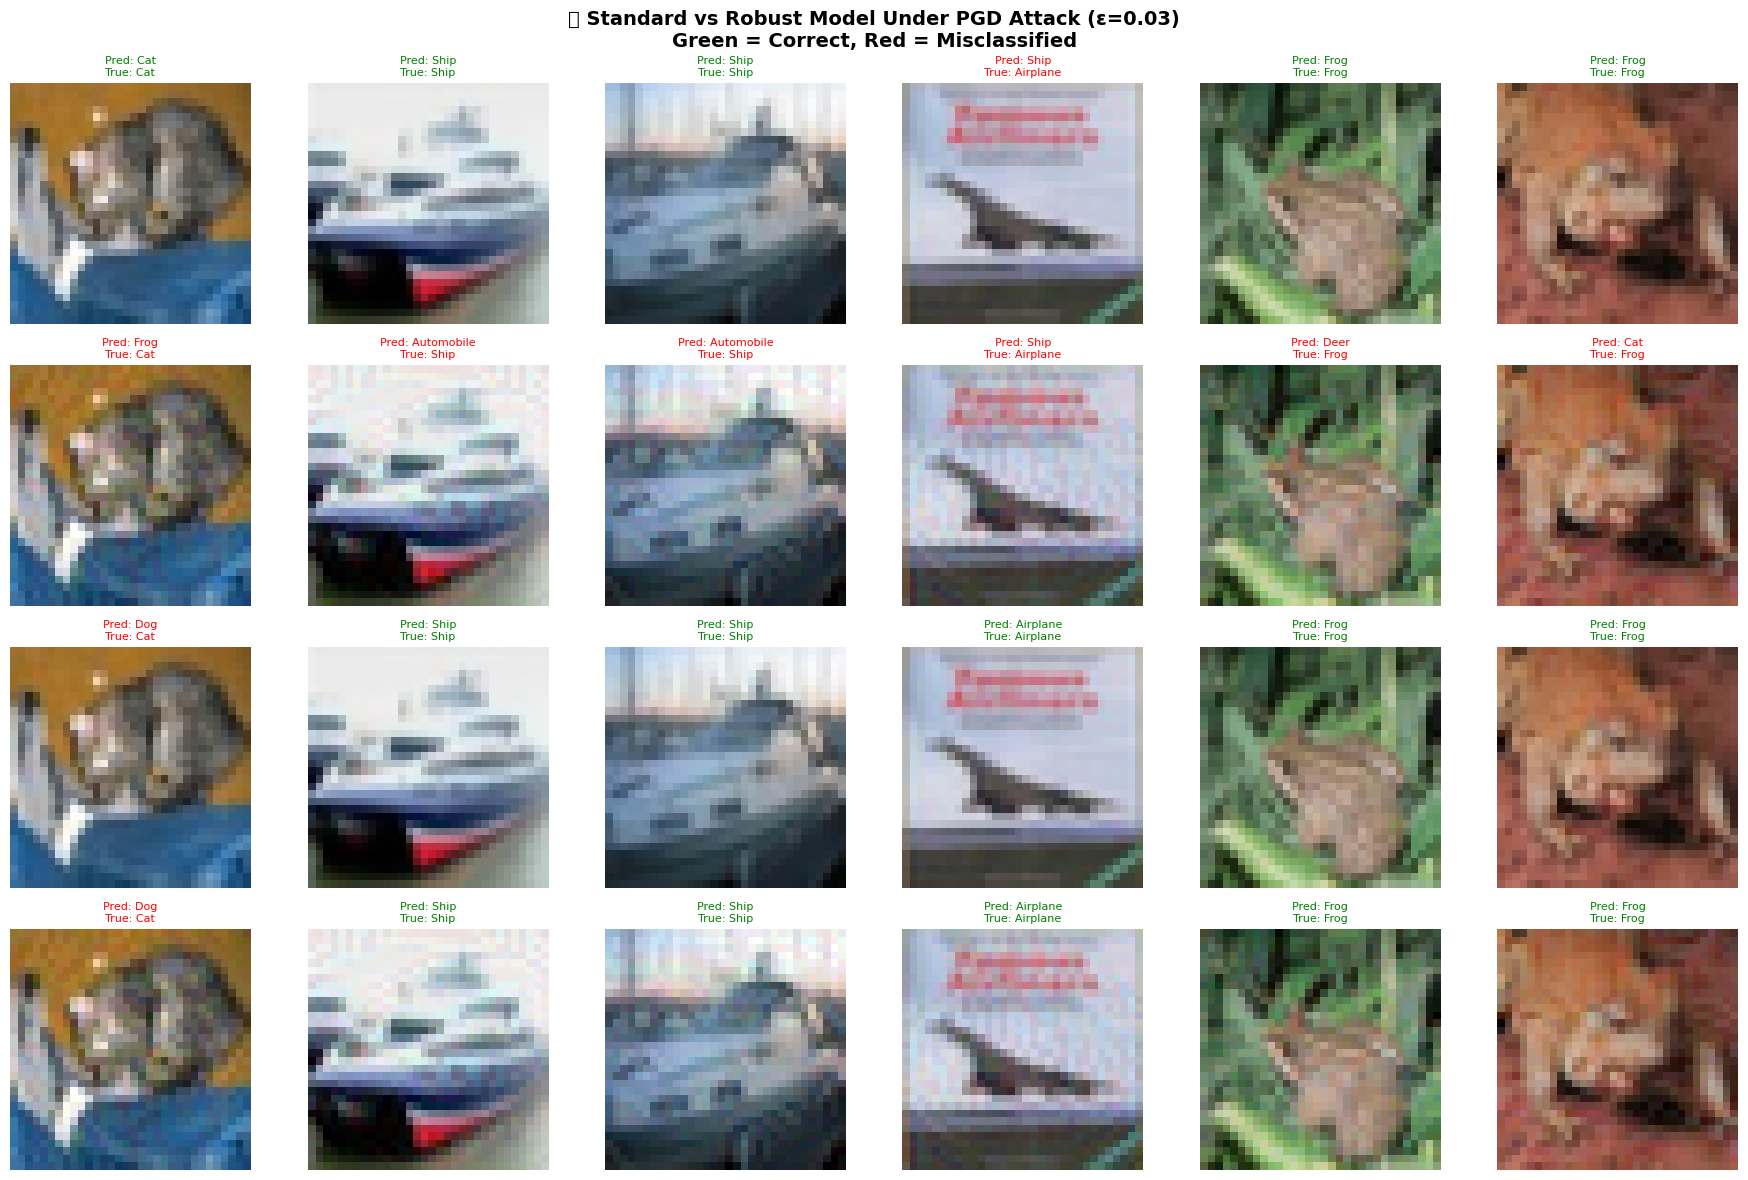

In [17]:
def compare_models_visual(standard_model, robust_model, testloader, epsilon=0.03):
    """Visually compare how standard and robust models handle adversarial images."""
    standard_model.eval()
    robust_model.eval()

    images, labels = next(iter(testloader))
    images, labels = images[:6].to(device), labels[:6].to(device)

    # Generate PGD attack (stronger attack)
    pgd_images = pgd_attack(standard_model, images.clone(), labels, epsilon)

    with torch.no_grad():
        std_clean_pred = standard_model(images).argmax(1)
        std_adv_pred = standard_model(pgd_images).argmax(1)
        rob_clean_pred = robust_model(images).argmax(1)
        rob_adv_pred = robust_model(pgd_images).argmax(1)

    fig, axes = plt.subplots(4, 6, figsize=(18, 12))
    titles = ['Original (Standard)', 'Attacked (Standard)',
              'Original (Robust)', 'Attacked (Robust)']
    all_imgs = [images, pgd_images, images, pgd_images]
    all_preds = [std_clean_pred, std_adv_pred, rob_clean_pred, rob_adv_pred]

    for row in range(4):
        for col in range(6):
            img = all_imgs[row][col].cpu().permute(1, 2, 0).numpy()
            axes[row][col].imshow(img)
            pred = all_preds[row][col].item()
            true = labels[col].item()
            color = 'green' if pred == true else 'red'
            axes[row][col].set_title(f'Pred: {classes[pred]}\nTrue: {classes[true]}',
                                      fontsize=8, color=color)
            axes[row][col].axis('off')
        axes[row][0].set_ylabel(titles[row], fontsize=10, fontweight='bold',
                                 rotation=0, labelpad=120)

    plt.suptitle(f'🔍 Standard vs Robust Model Under PGD Attack (ε={epsilon})\n'
                 f'Green = Correct, Red = Misclassified',
                 fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()

compare_models_visual(standard_model, robust_model, testloader, epsilon=0.03)

***## Final Summary & Results***

/tmp/ipykernel_1457/4135788978.py:37: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


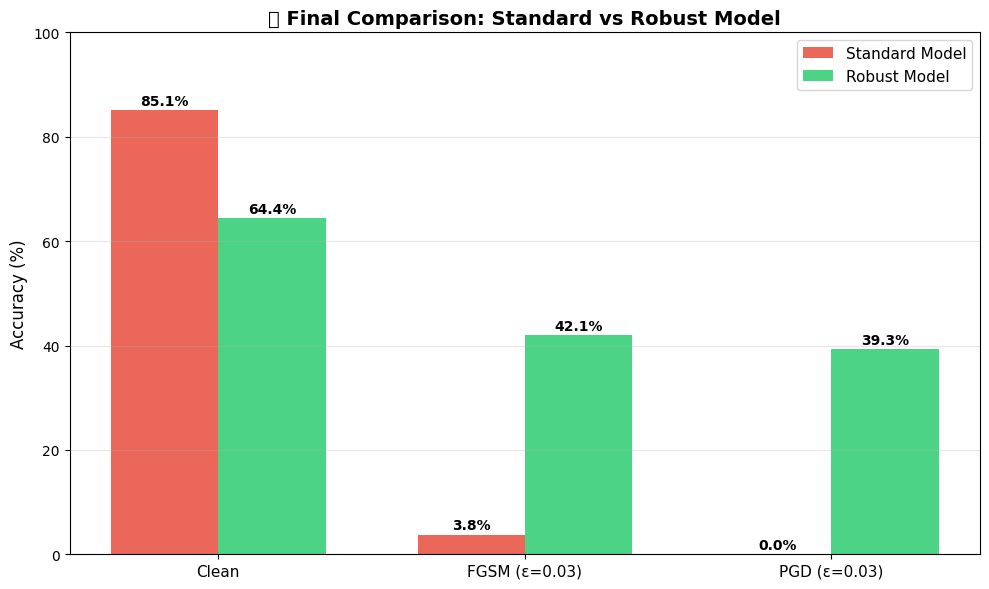


📋 FINAL RESULTS SUMMARY

🔹 Standard Model:
   Clean Accuracy:        85.14%
   FGSM Accuracy (ε=0.03): 3.76% (Drop: 81.38%)
   PGD Accuracy (ε=0.03):  0.00% (Drop: 85.14%)

🔹 Robust Model (Adversarial Training):
   Clean Accuracy:        64.42%
   FGSM Accuracy (ε=0.03): 42.06% (Drop: 22.36%)
   PGD Accuracy (ε=0.03):  39.31% (Drop: 25.11%)

✅ Robust model retains significantly more accuracy under attack!


In [20]:
import numpy as np

# Summary bar chart
eps_test = 0.03
std_fgsm = fgsm_accs[epsilons.index(eps_test)]
std_pgd = pgd_accs[epsilons.index(eps_test)]
rob_fgsm = robust_fgsm_accs[epsilons.index(eps_test)]
rob_pgd = robust_pgd_accs[epsilons.index(eps_test)]

categories = ['Clean', f'FGSM (ε={eps_test})', f'PGD (ε={eps_test})']
standard_scores = [clean_acc, std_fgsm, std_pgd]
robust_scores = [robust_clean_acc, rob_fgsm, rob_pgd]

x = np.arange(len(categories))
width = 0.35

fig, ax = plt.subplots(figsize=(10, 6))
bars1 = ax.bar(x - width/2, standard_scores, width, label='Standard Model', color='#e74c3c', alpha=0.85)
bars2 = ax.bar(x + width/2, robust_scores, width, label='Robust Model', color='#2ecc71', alpha=0.85)

ax.set_ylabel('Accuracy (%)', fontsize=12)
ax.set_title('📊 Final Comparison: Standard vs Robust Model', fontsize=14, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(categories, fontsize=11)
ax.legend(fontsize=11)
ax.set_ylim(0, 100)
ax.grid(axis='y', alpha=0.3)

# Add value labels on bars
for bar in bars1:
    ax.text(bar.get_x() + bar.get_width()/2., bar.get_height() + 1,
            f'{bar.get_height():.1f}%', ha='center', fontsize=10, fontweight='bold')
for bar in bars2:
    ax.text(bar.get_x() + bar.get_width()/2., bar.get_height() + 1,
            f'{bar.get_height():.1f}%', ha='center', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.show()

print('\n' + '=' * 60)
print('📋 FINAL RESULTS SUMMARY')
print('=' * 60)
print(f'\n🔹 Standard Model:')
print(f'   Clean Accuracy:        {clean_acc:.2f}%')
print(f'   FGSM Accuracy (ε=0.03): {std_fgsm:.2f}% (Drop: {clean_acc - std_fgsm:.2f}%)')
print(f'   PGD Accuracy (ε=0.03):  {std_pgd:.2f}% (Drop: {clean_acc - std_pgd:.2f}%)')
print(f'\n🔹 Robust Model (Adversarial Training):')
print(f'   Clean Accuracy:        {robust_clean_acc:.2f}%')
print(f'   FGSM Accuracy (ε=0.03): {rob_fgsm:.2f}% (Drop: {robust_clean_acc - rob_fgsm:.2f}%)')
print(f'   PGD Accuracy (ε=0.03):  {rob_pgd:.2f}% (Drop: {robust_clean_acc - rob_pgd:.2f}%)')
print(f'\n✅ Robust model retains significantly more accuracy under attack!')
print('=' * 60)